<a href="https://colab.research.google.com/github/sylwiabanasik/Praca_dyplomowa_SGH/blob/main/Badanie_roz%C5%82%C4%85czno%C5%9Bci_klas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import danych i podział na grupe treningowa i testowa

In [1]:
# import data
import numpy as np
from sklearn import  datasets
wine = datasets.load_wine()
wine.feature_names=['alco', 'mali', 'ash', 'alca', 'magn', 'phen', 'flav', 'nflav', 'proa', 'colo', 'hue', 'od280', 'prol']

In [2]:
# split data for train and test data
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
X = preprocessing.StandardScaler().fit(wine.data).transform(wine.data)
y = wine.target
X_train, X_test, y_train, y_test = \
train_test_split(X, y, stratify=wine.target, test_size=0.4, random_state=0)

# Badanie rozłączności klas

Rekomendowana ścieżka w praktyce (checklista)
*   PCA / UMAP – szybki rzut oka
*   Silhouette Score – liczbowy wskaźnik
*   Prosty klasyfikator + CV
*   Confusion Matrix
*   (Opcjonalnie) testy statystyczne

# Wizualna separowalność PCA (Rzutowanie do 2D / 3D)

Najpierw sprowadzasz dane do niskiego wymiaru i sprawdzasz, czy klasy się mieszają.

Najczęściej używane metody:
*   PCA – sprawdza separację liniową (bez użycia etykiet)
*   LDA –maksymalizuje separację klas (z etykietami)
*   t-SNE / UMAP – ujawniają nieliniowe struktury.

Interpretacja:
*   Wyraźne klastry bez nakładania → dobra rozłączność
*   Silne mieszanie → problem separowalności

Explained variance ratio:
[0.37552263 0.20186147 0.10845581 0.0687293  0.06021014 0.0523284
 0.03774835 0.02689743 0.02115281 0.01540672 0.01403482 0.01031522
 0.0073369 ]

Cumulative explained variance:
[0.37552263 0.57738409 0.68583991 0.75456921 0.81477935 0.86710775
 0.9048561  0.93175353 0.95290634 0.96831306 0.98234788 0.9926631
 1.        ]
Liczba komponentów wyjaśniających 90% wariancji: 7


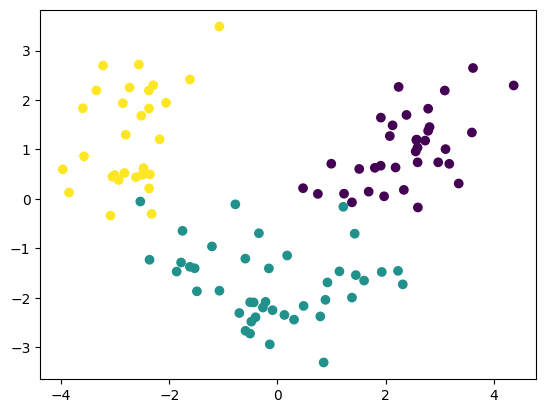

In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Dopasowanie PCA
pca = PCA().fit(X_train)

# Udział wariancji wyjaśnionej
explained_variance = pca.explained_variance_ratio_

# Suma skumulowana
cumulative_variance = np.cumsum(explained_variance)

# Wyświetlenie wyników
print("Explained variance ratio:")
print(explained_variance)

print("\nCumulative explained variance:")
print(cumulative_variance)

threshold = 0.90
n_components = np.argmax(cumulative_variance >= threshold) + 1
print(f"Liczba komponentów wyjaśniających {threshold*100:.0f}% wariancji: {n_components}")

X_pca = PCA(n_components=n_components).fit_transform(X_train)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train)
plt.show()


# Test Miary statystyczne rozłączności (obiektywna ocena)

a) Silhouette Score (najprostsza i bardzo skuteczna)

Mierzy:
*   jak blisko są punkty w obrębie klasy
*   jak daleko są od innych klas.

Interpretacja:
*   ~1.0 → klasy bardzo dobrze rozdzielone
*   ~0.0 → klasy się nakładają
*   <0.0 → błędne przypisania

In [4]:
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(X_train, y_train)
print(sil_score)

0.2909985017157734


b) Fisher Discriminant Ratio (FDR)

Klasyczna miara separowalności:
𝐹= (rozrzut między klasami) / (rozrzut wewnątrz klas)

Im większa wartość, tym lepsza separacja. Stosowana często: przy selekcji cech w analizie klasyfikatorów liniowych

c) Odległości między centroidami vs wariancja

Dla każdej pary klas: liczysz odległość między środkami klas porównujesz z rozrzutem wewnętrznym

Jeżeli distance(centroid_i, centroid_j) >> variance_i + variance_j → klasy są dobrze rozdzielone

# Test Ocena poprzez model (najbardziej praktyczna)

a) Prosty klasyfikator liniowy

Jeżeli prosty model (Logistic Regression, Linear SVM) ma wysoką skuteczność, to znaczy, że klasy są separowalne.

Reguła praktyczna:
*   wysoka skuteczność prostego modelu → dobra separacja
*   tylko złożone modele działają → separacja nieliniowa lub słaba

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

scores = cross_val_score(LogisticRegression(), X_train, y_train, cv=5)
print(scores.mean())

0.9523809523809523


b) Confusion Matrix

Sprawdzasz, które klasy się mylą.

Zwróć uwagę:

accuracy to za mało

patrz na recall / precision / F1

confusion matrix pokaże, które klasy się mylą

4. Testy statystyczne (gdy chcesz formalnego dowodu)

*   ANOVA / MANOVA – czy średnie klas różnią się istotnie
*   Kolmogorov–Smirnov – czy rozkłady cech w klasach się różnią
*   Bhattacharyya distance – miara nakładania się rozkładów

Stosowane głównie w: klasyfikacji medycznej, biometr ii, analizach regulowanych (compliance)

In [25]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=12)
selector.fit(X_train, y_train)

ranking = pd.DataFrame({
    "feature": wine.feature_names,
    "F_score": selector.scores_,
    "p_value": selector.pvalues_,
})

ranking = ranking.sort_values("F_score", ascending=False).reset_index(drop=True)

print(ranking.to_string(index=False))

feature    F_score      p_value
   flav 159.277548 3.027739e-32
   prol 144.821727 1.175443e-30
  od280 112.400985 1.279740e-26
   alco  85.662187 1.231688e-22
    hue  64.732357 6.219129e-19
   colo  64.001711 8.605354e-19
   phen  58.645041 9.928359e-18
  nflav  32.503220 1.139808e-11
   mali  26.509088 5.159342e-10
   alca  18.649766 1.223831e-07
   proa  15.478655 1.325399e-06
   magn   9.633068 1.461667e-04
    ash   6.999537 1.411635e-03


In [6]:
#ANOVA
from sklearn.feature_selection import f_classif
import pandas as pd

F, p_values = f_classif(X_train, y_train)

anova_results = pd.DataFrame({
    "feature": wine.feature_names,
    "F_statistic": F,
    "p_value": p_values
}).sort_values("p_value")

print(anova_results)

   feature  F_statistic       p_value
6     flav   159.277548  3.027739e-32
12    prol   144.821727  1.175443e-30
11   od280   112.400985  1.279740e-26
0     alco    85.662187  1.231688e-22
10     hue    64.732357  6.219129e-19
9     colo    64.001711  8.605354e-19
5     phen    58.645041  9.928359e-18
7    nflav    32.503220  1.139808e-11
1     mali    26.509088  5.159342e-10
3     alca    18.649766  1.223831e-07
8     proa    15.478655  1.325399e-06
4     magn     9.633068  1.461667e-04
2      ash     6.999537  1.411635e-03


In [23]:
import numpy as np
import pandas as pd
from itertools import combinations
from scipy.stats import ks_2samp

# indeksy wybranych cech w oryginalnym X
selected_idx = selector.get_support(indices=True)
selected_names = [wine.feature_names[i] for i in selected_idx]

classes = sorted(np.unique(y_train))
pairs = list(combinations(classes, 2))

rows = []
for feat_i, feat_name in enumerate(selected_names):
    for c1, c2 in pairs:
        x1 = X_train_sel[y_train == c1, feat_i]
        x2 = X_train_sel[y_train == c2, feat_i]

        stat, p = ks_2samp(x1, x2)  # D-statistic i p-value
        rows.append({
            "feature": feat_name,
            "class_pair": f"{c1} vs {c2}",
            "KS_statistic_D": stat,
            "p_value": p
        })
ks_table = pd.DataFrame(rows).sort_values(["p_value", "KS_statistic_D"], ascending=[True, False])

ks_table["max_KS_per_feature"] = (
    ks_table.groupby("feature")["KS_statistic_D"]
    .transform("max")
)

ks_table_sorted = ks_table.sort_values(
    by=["max_KS_per_feature", "feature"],
    ascending=[False, True]
)
print(ks_table_sorted.to_string(index=False))


feature class_pair  KS_statistic_D      p_value  max_KS_per_feature
   flav     0 vs 2        1.000000 1.440073e-18            1.000000
   flav     1 vs 2        0.907225 1.310430e-15            1.000000
   flav     0 vs 1        0.780952 4.550595e-12            1.000000
  od280     0 vs 2        1.000000 1.440073e-18            1.000000
  od280     1 vs 2        0.870279 6.473447e-14            1.000000
  od280     0 vs 1        0.333333 2.206732e-02            1.000000
   prol     0 vs 1        0.919048 1.217025e-17            0.919048
   prol     0 vs 2        0.885714 1.110700e-13            0.919048
   prol     1 vs 2        0.457307 8.847537e-04            0.919048
   phen     0 vs 2        0.902463 4.976893e-14            0.902463
   phen     0 vs 1        0.633333 1.012589e-07            0.902463
   phen     1 vs 2        0.568144 1.148699e-05            0.902463
   alco     0 vs 1        0.880952 3.839740e-16            0.880952
   alco     1 vs 2        0.650246 2.049979e-07 

#  -  pipeline modelowania PCA

Ewaluacja modelu

Zwróć uwagę: accuracy to za mało / patrz na recall, precision, F1 /
confusion matrix pokaże, które klasy się mylą

Najczęstsze błędy (unikaj!)
*   PCA przed train/test split ❌
*   PCA bez skalowania ❌
*   Brak porównania z modelem bez PCA ❌
*   Interpretowanie PC jako oryginalnych cech ❌

Po wyborze n_components = 7 budujesz pipeline: skalowanie → PCA → model, uczysz go wyłącznie na train, porównujesz z wersją bez PCA i dopiero wtedy decydujesz, czy PCA zostaje w finalnym rozwiązaniu.

In [8]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=7)),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.96      1.00      0.98        24
           1       1.00      0.97      0.98        29
           2       1.00      1.00      1.00        19

    accuracy                           0.99        72
   macro avg       0.99      0.99      0.99        72
weighted avg       0.99      0.99      0.99        72

[[24  0  0]
 [ 1 28  0]
 [ 0  0 19]]


# pipline modelowania noPCA

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        24
           1       1.00      0.97      0.98        29
           2       1.00      1.00      1.00        19

    accuracy                           0.99        72
   macro avg       0.99      0.99      0.99        72
weighted avg       0.99      0.99      0.99        72

[[24  0  0]
 [ 1 28  0]
 [ 0  0 19]]


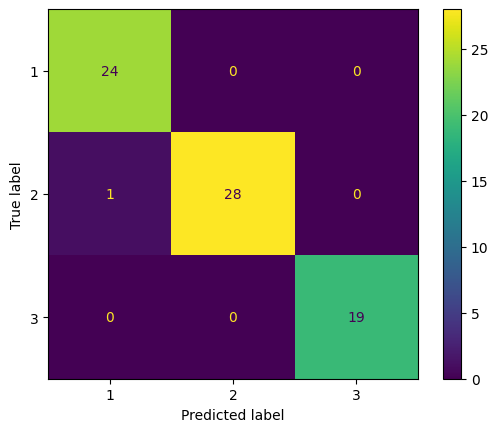

In [9]:

pipeline_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline_no_pca.fit(X_train, y_train)
y_pred_no_pca = pipeline_no_pca.predict(X_test)

print(classification_report(y_test, y_pred_no_pca))
print(confusion_matrix(y_test, y_pred_no_pca))

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_no_pca,
    display_labels=[1,2,3]
)

Porównanie: z PCA vs bez PCA (OBOWIĄZKOWE)

Porównaj metryki:

jeżeli PCA poprawia wynik → zostaje

jeżeli pogarsza → PCA do kosza

# Strojenie hiperparametrów (GridSearch)

In [10]:
# @title
from sklearn.model_selection import GridSearchCV

param_grid = {
    'pca__n_components': [4, 5, 7, 9],
    'model__C': [0.2, 1, 10]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=4,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)
print(grid.best_params_)

{'model__C': 0.2, 'pca__n_components': 4}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


# Interpretacja po PCA (opcjonalna)

To pozwala:

zobaczyć, które cechy dominują w PC1–PC7

NIE do interpretacji biznesowej, tylko analitycznej

In [11]:
pca = pipeline.named_steps['pca']
loadings = pca.components_
print(loadings)

[[ 0.13542787 -0.2566344  -0.02197862 -0.24283929  0.14985086  0.37769991
   0.40574674 -0.33496393  0.29141013 -0.08492699  0.3222577   0.36924263
   0.28649213]
 [ 0.49466437  0.21856159  0.29020599 -0.06663193  0.3023724   0.09519153
  -0.00549091  0.0777433   0.05686305  0.5263215  -0.21627206 -0.22118661
   0.36928195]
 [-0.16502885  0.0765791   0.66985099  0.61478659  0.09177709  0.16829455
   0.18182855  0.10386978  0.05150775 -0.11916904  0.05230345  0.18619542
  -0.07336808]
 [-0.26544235  0.22288056 -0.20964678  0.06956281  0.03194286  0.15083036
   0.08947042 -0.14923038  0.68291403  0.19054724 -0.44611955 -0.00833877
  -0.27433016]
 [-0.24567058 -0.06435607  0.00539775 -0.02303692  0.8516929  -0.23344368
  -0.20273669 -0.27708247 -0.04639312 -0.14702998  0.03740673 -0.10019838
  -0.04451638]
 [ 0.12679132  0.84963203 -0.05622697 -0.1076508   0.00237475  0.04749049
   0.03810075 -0.20213487 -0.15204956 -0.38393959  0.01319496  0.16849962
   0.06027552]
 [-0.05267511  0.15259

# Produkcja / inference

Na produkcji:

zapisujesz cały pipeline (joblib)

nigdy nie uczysz PCA ponownie

In [12]:
import joblib
joblib.dump(pipeline, "model.pkl")

['model.pkl']

Inne modele, które dobrze współpracują z PCA
Dobre po PCA:
*   Logistic Regression
*   Linear SVM
*   kNN
*   Naive Bayes
*   Neural Networks
Słabe po PCA:
*   drzewa decyzyjne
*   Random Forest
*   XGBoost

Dlaczego: drzewa lubią oryginalne, interpretowalne cechy